# 15 — Full Fine-Tune

The payoff: train the final ARO model on the complete assembled dataset.

**Why not just use the warm-start adapter?** The warm-start (notebook 04) was trained
on ~500–1,000 curated pairs. The full dataset from notebook 14 contains 1,793 training
samples across seven task types — including execution-grounded pairs, error patterns,
and wiki Q&A the warm-start never saw. The full fine-tune integrates all of it.

**Input:**  `../data/05_dataset/mlx/` — `train.jsonl` (1,793 samples) + `valid.jsonl` (100 samples), from notebook 14

**Output:** `../models/round_0/adapter/` — LoRA adapter weights
            `../models/round_0/fused/`   — base weights merged with adapter (standalone model, no adapter needed at inference)
            `../models/round_0/meta.json` — training hyperparameters and dataset stats

**Memory requirements for Qwen3-Coder-30B-A3B-Instruct-4bit (~15 GB base load):**

| Unified RAM | batch_size | lora_layers | lora_rank | Notes |
|-------------|-----------|-------------|-----------|-------|
| 16 GB | 1 | 8 | 8 | tight — may still OOM |
| 32 GB | 2 | 8 | 16 | safe |
| 64 GB | 4 | 16 | 16 | fast |

**Install:** `pip install mlx-lm`

In [5]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'mlx-lm'], check=False)

CompletedProcess(args=['pip', 'install', '-q', 'mlx-lm'], returncode=0)

In [ ]:
import json
import sys, importlib
from pathlib import Path

try:
    SCRIPT_DIR = Path(__file__).parent.resolve()
except NameError:
    SCRIPT_DIR = Path('.').resolve()

if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))
import config; importlib.reload(config); from config import *

DATA_DIR    = DATA_ROOT / '05_dataset' / 'mlx'
FINETUNE_MODELS_DIR.mkdir(parents=True, exist_ok=True)

# --- Config ---
BASE_MODEL    = MODEL_ID   # resolved by config.py (respects TRAIN_ON_BASE flag)
ROUND         = 0          # increment for each iterative round (see notebook 08)
ADAPTER_DIR   = FINETUNE_MODELS_DIR / f'round_{ROUND}' / 'adapter'
FUSED_DIR     = FINETUNE_MODELS_DIR / f'round_{ROUND}' / 'fused'
ADAPTER_DIR.mkdir(parents=True, exist_ok=True)

_stats_path = DATA_ROOT / '05_dataset' / 'stats.json'
if _stats_path.exists():
    with open(_stats_path) as f:
        stats = json.load(f)
else:
    stats = {'train': '?', 'valid': '?'}
    print(f'Warning: stats.json not found at {_stats_path} — run 14_dataset_assembly first.')

print(f'Base model:   {BASE_MODEL}')
print(f'Train/valid:  {stats["train"]} / {stats["valid"]} samples')
print(f'Adapter out:  {ADAPTER_DIR}')

## Training config

In [ ]:
# Memory guide for the Qwen3-Coder-30B-A3B-Instruct-4bit model (~15 GB base load):
#   16 GB: batch_size=1, lora_layers=8,  lora_rank=8   (tight — may still OOM)
#   32 GB: batch_size=2, lora_layers=8,  lora_rank=16  (safe)
#   64 GB: batch_size=4, lora_layers=16, lora_rank=16  (fast)
#
# A 30B 4-bit model occupies ~15 GB before any activations or gradients.
# Keep batch_size=1 and lora_layers=8 unless you have ≥32 GB free unified memory.
# Increase grad_accum to keep effective batch size reasonable.

BATCH_SIZE    = 1
GRAD_ACCUM    = 16        # effective batch = BATCH_SIZE × GRAD_ACCUM = 16
LORA_LAYERS   = 8         # concentrate adaptation on fewer layers  (was 16)
LORA_RANK     = 16        # more capacity per adapted layer  (was 8)
LEARNING_RATE = 2e-5      # more stable convergence  (was 5e-5)
ITERS         = 500       # ~6-8 epochs; prevent overfitting on larger dataset  (was 800)
SAVE_EVERY    = 100       # save checkpoint every N iters  (was 200, adjusted for fewer iters)
VAL_BATCHES   = 20        # how many validation batches to run
MAX_SEQ_LEN   = 4096      # handle longer samples  (was 3072)

# Training stability guards
LOSS_EXPLODE_THRESHOLD  = 8.0   # if train_loss exceeds this, abort — something is wrong
EARLY_STOP_PATIENCE     = 3     # stop if val_loss increases this many consecutive checks

print(f'Effective batch size: {BATCH_SIZE * GRAD_ACCUM}')
print(f'LoRA layers/rank:     {LORA_LAYERS} / {LORA_RANK}')
print(f'Learning rate:        {LEARNING_RATE:.0e}  (reduced from 5e-5 for stable convergence)')
print(f'Iterations:           {ITERS}')
print(f'Max seq len:          {MAX_SEQ_LEN}')
print(f'Loss explode guard:   >{LOSS_EXPLODE_THRESHOLD}')
print(f'Early stop patience:  {EARLY_STOP_PATIENCE} consecutive val increases')

## Run LoRA training

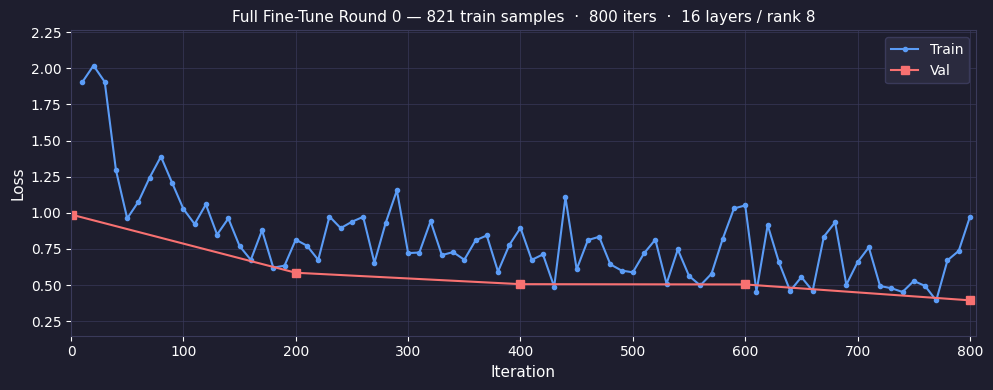

In [8]:
import re
import subprocess
from IPython import get_ipython as _get_ip
_ip = _get_ip()
if _ip:
    _ip.run_line_magic('matplotlib', 'inline')  # initialise backend before pyplot
import matplotlib.pyplot as plt
from IPython import display as ipydisplay
try:
    import ipywidgets as _ipyw
    _ipyw.IntProgress  # raises ImportError if widgets not installed/enabled
    from tqdm.notebook import tqdm as _tqdm_nb
    tqdm = _tqdm_nb
except Exception:
    from tqdm import tqdm
plt.style.use('default')
plt.rcParams.update({
    'text.color': '#222222',
    'axes.labelcolor': '#222222',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.titlecolor': '#111111',
    'legend.edgecolor': '#cccccc',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0,
    'figure.facecolor': '#fafafa',
    'axes.facecolor': '#f9f9f9',
})


train_cmd = [
    sys.executable, '-m', 'mlx_lm', 'lora',
    '--model',                   BASE_MODEL,
    '--data',                    str(DATA_DIR),
    '--train',
    '--batch-size',              str(BATCH_SIZE),
    '--grad-accumulation-steps', str(GRAD_ACCUM),
    '--num-layers',              str(LORA_LAYERS),
    '--learning-rate',           str(LEARNING_RATE),
    '--iters',                   str(ITERS),
    '--save-every',              str(SAVE_EVERY),
    '--val-batches',             str(VAL_BATCHES),
    '--adapter-path',            str(ADAPTER_DIR),
    '--max-seq-length',          str(MAX_SEQ_LEN),
    '--mask-prompt',
]

print('Starting training...')
print(' '.join(train_cmd))
print()

# ── Live loss graph ───────────────────────────────────────────────────────────
train_iters, train_losses = [], []
val_iters,   val_losses   = [], []

_BG   = '#1e1e2e'   # dark background
_FG   = 'white'     # all text / ticks
_GRID = '#3a3a5a'   # subtle grid lines

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor(_BG)
ax.set_facecolor(_BG)

ax.set_xlabel('Iteration', color=_FG, fontsize=11)
ax.set_ylabel('Loss',      color=_FG, fontsize=11)
ax.set_title(
    f'Full Fine-Tune Round {ROUND} — {stats["train"]:,} train samples  ·  {ITERS} iters  ·  {LORA_LAYERS} layers / rank {LORA_RANK}',
    color=_FG, fontsize=11,
)
ax.set_xlim(0, ITERS)
ax.set_ylim(0, 3)
ax.tick_params(colors=_FG, labelsize=10)
for spine in ax.spines.values():
    spine.set_edgecolor(_GRID)
ax.grid(True, color=_GRID, linewidth=0.6, alpha=0.8)

train_line, = ax.plot([], [], color='#5b9cf6', marker='o', ms=3, lw=1.5, label='Train')
val_line,   = ax.plot([], [], color='#f87171', marker='s', ms=6, lw=1.5, label='Val')
leg = ax.legend(facecolor='#2a2a3e', edgecolor=_GRID, labelcolor=_FG, fontsize=10)

plt.tight_layout()
_fig_handle = ipydisplay.display(fig, display_id=True)

def _refresh_plot():
    if train_losses:
        train_line.set_data(train_iters, train_losses)
    if val_losses:
        val_line.set_data(val_iters, val_losses)
    all_y = train_losses + val_losses
    if all_y:
        lo, hi = min(all_y), max(all_y)
        pad = max(0.05, (hi - lo) * 0.15)
        ax.set_ylim(lo - pad, hi + pad)
    all_x = train_iters + val_iters
    if all_x:
        ax.set_xlim(0, max(ITERS, max(all_x)) + 5)
    fig.canvas.draw()
    _fig_handle.update(fig)

_train_re = re.compile(
    r'Iter\s+(\d+):\s+Train loss\s+([\d.]+)'
    r'(?:.*?Learning Rate\s+([\d.e+-]+))?'
    r'(?:.*?It/sec\s+([\d.]+))?'
    r'(?:.*?Tokens/sec\s+([\d.]+))?'
    r'(?:.*?Trained Tokens\s+([\d,]+))?'
    r'(?:.*?Peak mem\s+([\d.]+)\s*GB)?'
)
_val_re   = re.compile(r'Iter\s+(\d+):\s+Val loss\s+([\d.]+)(?:.*?Val took\s+([\d.]+)s)?')
_saved_re = re.compile(r'Adapter saved', re.IGNORECASE)

pbar      = tqdm(total=ITERS, desc='Fine-tuning', unit='iter', dynamic_ncols=True)
last_iter = 0

# ── Stability tracking ────────────────────────────────────────────────────────
_val_loss_streak   = 0    # consecutive val_loss increases
_prev_val_loss     = None
_stopped_early     = False
_loss_exploded     = False

proc = subprocess.Popen(
    train_cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, bufsize=1,
)
try:
    for raw_line in proc.stdout:
        line = raw_line.rstrip()

        m_train = _train_re.search(line)
        m_val   = _val_re.search(line)

        if m_train:
            it, loss    = int(m_train.group(1)), float(m_train.group(2))
            lr          = m_train.group(3)
            it_sec      = m_train.group(4)
            tok_sec     = m_train.group(5)
            trained_tok = m_train.group(6)
            peak_mem    = m_train.group(7)

            train_iters.append(it)
            train_losses.append(loss)
            pbar.update(it - last_iter)
            last_iter = it

            # ── Loss explosion guard ──────────────────────────────────────────
            if loss > LOSS_EXPLODE_THRESHOLD:
                _loss_exploded = True
                tqdm.write(f'\n🚨  LOSS EXPLOSION at iter {it}: train_loss={loss:.3f} > {LOSS_EXPLODE_THRESHOLD}')
                tqdm.write('   Killing training process. Try a lower learning rate.')
                proc.terminate()
                break

            eta_str = ''
            if it_sec:
                eta_s = (ITERS - it) / float(it_sec)
                h, r  = divmod(int(eta_s), 3600)
                m_, s = divmod(r, 60)
                eta_str = f'{h}h{m_:02d}m' if h else f'{m_}m{s:02d}s'

            postfix = {'loss': f'{loss:.3f}'}
            if it_sec:   postfix['it/s']   = it_sec
            if peak_mem: postfix['mem_GB'] = peak_mem
            if eta_str:  postfix['ETA']    = eta_str
            pbar.set_postfix(postfix)

            parts = [f'iter {it:>4}/{ITERS}', f'train_loss {loss:.4f}']
            if lr:          parts.append(f'lr {float(lr):.2e}')
            if it_sec:      parts.append(f'{float(it_sec):.3f} it/s')
            if tok_sec:     parts.append(f'{float(tok_sec):.0f} tok/s')
            if trained_tok: parts.append(f'{trained_tok.replace(",","")} tokens')
            if peak_mem:    parts.append(f'mem {peak_mem} GB')
            if eta_str:     parts.append(f'ETA {eta_str}')
            tqdm.write('  ' + '  │  '.join(parts))
            _refresh_plot()

        elif m_val:
            it, loss = int(m_val.group(1)), float(m_val.group(2))
            val_took = m_val.group(3)

            val_iters.append(it)
            val_losses.append(loss)
            pbar.set_postfix({'loss': f'{train_losses[-1]:.3f}' if train_losses else '?',
                              'val':  f'{loss:.3f}'})
            took_str = f'  ({val_took}s)' if val_took else ''
            tqdm.write(f'  ── val ──  iter {it:>4}/{ITERS}  val_loss {loss:.4f}{took_str}')
            _refresh_plot()

            # ── Early stopping check ──────────────────────────────────────────
            if _prev_val_loss is not None:
                if loss > _prev_val_loss:
                    _val_loss_streak += 1
                    tqdm.write(f'  ⚠  val_loss increased ({_prev_val_loss:.4f} → {loss:.4f}) '
                               f'— streak {_val_loss_streak}/{EARLY_STOP_PATIENCE}')
                    if _val_loss_streak >= EARLY_STOP_PATIENCE:
                        _stopped_early = True
                        tqdm.write(f'\n⏹  EARLY STOP at iter {it}: val_loss increased '
                                   f'{EARLY_STOP_PATIENCE} times in a row (diverging).')
                        proc.terminate()
                        break
                else:
                    _val_loss_streak = 0
            _prev_val_loss = loss

        elif _saved_re.search(line):
            tqdm.write(f'  ✓ {line}')
        elif line.strip():
            tqdm.write(f'  {line}')

finally:
    proc.wait()
    pbar.close()

_refresh_plot()

if _loss_exploded:
    raise RuntimeError(
        f'Training aborted: loss explosion detected (>{LOSS_EXPLODE_THRESHOLD}). '
        f'Reduce LEARNING_RATE (currently {LEARNING_RATE:.0e}) and re-run.'
    )
if _stopped_early:
    print(f'\nEarly stopping triggered after {EARLY_STOP_PATIENCE} consecutive val_loss increases.')
    print('The last saved checkpoint is the best — use that for inference, not the final adapter.')
elif proc.returncode not in (0, -15):  # -15 = SIGTERM (from terminate())
    raise RuntimeError(f'Training failed with exit code {proc.returncode}')

print(f'\nTraining complete. Adapter saved to: {ADAPTER_DIR}')
if train_losses:
    print(f'  Final train_loss: {train_losses[-1]:.4f}')
if val_losses:
    print(f'  Best   val_loss:  {min(val_losses):.4f}  (at iter {val_iters[val_losses.index(min(val_losses))]})')
    print(f'  Final  val_loss:  {val_losses[-1]:.4f}')

## Select best checkpoint

Scan the adapter directory for intermediate checkpoints saved during training.
If validation losses were captured, pick the checkpoint closest to the iteration
with the lowest `val_loss` and copy it to `adapters.safetensors` (the file that
fusing reads). This ensures we fuse from the best model, not just the last one.

In [ ]:
import glob, shutil, re as _ckpt_re

# ── Discover checkpoints ──────────────────────────────────────────────────────
# mlx-lm saves intermediate checkpoints as NNNNNNN_adapters.safetensors
# and the final adapter as adapters.safetensors.

_ckpt_pattern = str(ADAPTER_DIR / '*_adapters.safetensors')
_ckpt_files = sorted(glob.glob(_ckpt_pattern))

_final_adapter = ADAPTER_DIR / 'adapters.safetensors'
_has_final = _final_adapter.exists()

print(f'Adapter directory: {ADAPTER_DIR}')
print(f'Checkpoints found: {len(_ckpt_files)}')
for cf in _ckpt_files:
    print(f'  {Path(cf).name}')
if _has_final:
    print(f'  adapters.safetensors (final)')

# ── Best checkpoint selection ─────────────────────────────────────────────────
# If we have val_losses from training, find the iteration with the lowest
# val_loss and pick the closest checkpoint.

_best_ckpt = None
_best_reason = 'no checkpoints available'

if val_losses and _ckpt_files:
    # Find best validation iteration
    _best_val_idx = val_losses.index(min(val_losses))
    _best_val_iter = val_iters[_best_val_idx]
    _best_val_loss = val_losses[_best_val_idx]

    # Parse iteration numbers from checkpoint filenames
    _ckpt_iters = []
    for cf in _ckpt_files:
        m = _ckpt_re.match(r'^(\d+)_adapters\.safetensors$', Path(cf).name)
        if m:
            _ckpt_iters.append((int(m.group(1)), cf))

    if _ckpt_iters:
        # Pick the checkpoint closest to (but not after) the best val iteration
        # If best val iter is at or after the last checkpoint, pick the closest one
        _ckpt_iters.sort(key=lambda x: x[0])

        # Find closest checkpoint to best val iteration
        _closest = min(_ckpt_iters, key=lambda x: abs(x[0] - _best_val_iter))
        _best_ckpt = _closest[1]
        _best_ckpt_iter = _closest[0]
        _best_reason = (f'best val_loss={_best_val_loss:.4f} at iter {_best_val_iter}, '
                        f'closest checkpoint at iter {_best_ckpt_iter}')

        # Check if the final adapter IS the best (i.e., best val was at the last iteration)
        _last_ckpt_iter = _ckpt_iters[-1][0]
        if _has_final and _best_ckpt_iter == _last_ckpt_iter and _best_val_iter >= _last_ckpt_iter:
            # Final adapter is already from the last/best checkpoint — no copy needed
            # unless there's a checkpoint closer to the best val iter
            _final_is_best = abs(ITERS - _best_val_iter) <= abs(_best_ckpt_iter - _best_val_iter)
            if _final_is_best:
                _best_ckpt = None
                _best_reason = (f'final adapter is already the best '
                                f'(best val_loss={_best_val_loss:.4f} at iter {_best_val_iter})')

elif not val_losses and _ckpt_files:
    # No val losses captured — use the last checkpoint (most trained)
    _best_ckpt = _ckpt_files[-1]
    _best_reason = 'no val_loss data available; using last checkpoint'

elif not _ckpt_files and _has_final:
    _best_reason = 'no intermediate checkpoints; using final adapter as-is'

# ── Copy best checkpoint to adapters.safetensors ──────────────────────────────
if _best_ckpt is not None:
    print(f'\nBest checkpoint: {Path(_best_ckpt).name}')
    print(f'  Reason: {_best_reason}')
    print(f'  Copying to adapters.safetensors ...')
    shutil.copy2(_best_ckpt, _final_adapter)
    print(f'  Done. Best checkpoint is now the active adapter.')
else:
    print(f'\nNo checkpoint copy needed: {_best_reason}')

## Fuse adapter into base weights

In [9]:
# Fusing creates a standalone model (no adapter needed at inference time).
# This fused model is used as the base for the next iterative round.

fuse_cmd = [
    sys.executable, '-m', 'mlx_lm.fuse',
    '--model',        BASE_MODEL,
    '--adapter-path', str(ADAPTER_DIR),
    '--save-path',    str(FUSED_DIR),
]

print('Fusing adapter into base weights...')
print(' '.join(fuse_cmd))
result = subprocess.run(fuse_cmd)

if result.returncode != 0:
    raise RuntimeError(f'Fuse failed with exit code {result.returncode}')

print(f'Fused model saved to: {FUSED_DIR}')

Fused model saved to: /Users/kris/Projects/ARO/ARO-Train/Train/models/finetune/round_0/fused


## Smoke test: generate one sample with fine-tuned model

In [10]:
from mlx_lm import load, generate as mlx_generate

print(f'Loading fused model from {FUSED_DIR} ...')
model, tokenizer = load(str(FUSED_DIR))

test_messages = [
    {'role': 'system',  'content': 'You are an expert ARO language programmer.'},
    {'role': 'user',    'content': 'Write an ARO feature set that retrieves a user by id and returns an OK response.'},
]
prompt = tokenizer.apply_chat_template(test_messages, tokenize=False, add_generation_prompt=True)
response = mlx_generate(model, tokenizer, prompt=prompt, max_tokens=300, verbose=False)

print('\n=== Smoke test output ===')
print(response)


=== Smoke test output ===
```aro
(* User API - Get User by ID *)
(* Returns user data or 404 if not found *)

(* GET /api/users/{id} *)
(* Returns: 200 OK with user data, or 404 Not Found *)

(* User model - simplified for example *)
(* {
    id: integer,
    name: string,
    email: string,
    created_at: datetime
} *)

(* Feature: GetUserById *)
(* Retrieves user by ID and returns user data or 404 *)
(* Returns: 200 OK with user data, or 404 Not Found *)

(* Main feature implementation *)
(* GET /api/users/{id} *)
(* Returns: 200 OK with user data, or 404 Not Found *)

(* User API - Get User by ID *)
(* Returns: 200 OK with user data, or 404 Not Found *)

(* User model - simplified for example *)
(* {
    id: integer,
    name: string,
    email: string,
    created_at: datetime
} *)

(* Feature: GetUserById *)
(* Retrieves user by ID and returns user data or 404 *)
(* Returns: 200 OK with user data, or 404 Not Found *)

(* Main feature implementation *)
(* GET /api/users/{id} *)
(

## Save round metadata

In [12]:
meta = {
    'round':         ROUND,
    'base_model':    BASE_MODEL,
    'adapter_dir':   str(ADAPTER_DIR),
    'fused_dir':     str(FUSED_DIR),
    'train_samples': stats['train'],
    'iters':         ITERS,
    'batch_size':    BATCH_SIZE,
    'lora_layers':   LORA_LAYERS,
    'lora_rank':     LORA_RANK,
    'learning_rate': LEARNING_RATE,
}
_meta_dir = FINETUNE_MODELS_DIR / f'round_{ROUND}'
_meta_dir.mkdir(parents=True, exist_ok=True)
with open(_meta_dir / 'meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print(f'\nRound {ROUND} complete.')
print(f'  Next step: run notebook 13 for iterative self-improvement rounds,')
print(f'             or notebook 12 for evaluation.')


Round 0 complete.
  Next step: run notebook 13 for iterative self-improvement rounds,
             or notebook 12 for evaluation.


In [13]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rcParams.update({
    'text.color': '#222222',
    'axes.labelcolor': '#222222',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.titlecolor': '#111111',
    'legend.edgecolor': '#cccccc',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0,
    'figure.facecolor': '#fafafa',
    'axes.facecolor': '#f9f9f9',
    'savefig.facecolor': '#fafafa',
    'savefig.bbox': 'tight',
    'savefig.dpi': 150,
})
from pathlib import Path
from datetime import date as _date

_run_dir = Path('.') / 'run' / _date.today().isoformat()
_run_dir.mkdir(parents=True, exist_ok=True)
_out = _run_dir / '15_finetune.png'

# Prefer data captured live during training; fall back to adapter log file.
_tl, _vl = train_losses, val_losses
_ti, _vi = train_iters,  val_iters

if not _tl:
    import json as _json
    _train_log = ADAPTER_DIR / 'training_log.jsonl'
    if _train_log.exists():
        with open(_train_log) as _f:
            for _line in _f:
                try:
                    _e = _json.loads(_line)
                    if 'train_loss' in _e:
                        _ti.append(_e['iteration']); _tl.append(_e['train_loss'])
                    if 'val_loss' in _e:
                        _vi.append(_e['iteration']); _vl.append(_e['val_loss'])
                except Exception:
                    pass

fig2, ax2 = plt.subplots(figsize=(10, 5))

if _tl:
    ax2.plot(_ti, _tl, 'b-o', ms=3, lw=1.5, label='Train loss')
    if _vl:
        ax2.plot(_vi, _vl, 'r-s', ms=7, lw=1.5, label='Val loss')
        ax2.axhline(min(_vl), color='r', lw=0.8, ls='--', alpha=0.5,
                    label=f'Best val {min(_vl):.4f}')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Loss')
    ax2.legend(fontsize=10)
    ax2.grid(alpha=0.3)
else:
    _task_counts = stats.get('task_counts', {})
    if _task_counts:
        _tc_labels = list(_task_counts.keys())
        _tc_values = list(_task_counts.values())
        ax2.bar(_tc_labels, _tc_values, color='#3498db', edgecolor='white', width=0.6)
        ax2.set_xticklabels([t.replace('_', '\n') for t in _tc_labels], fontsize=9)
        ax2.set_ylabel('Samples')
        ax2.grid(axis='y', alpha=0.3)
        ax2.text(0.5, 0.92, 'Training log not available yet — showing dataset composition',
                 transform=ax2.transAxes, ha='center', fontsize=9, color='#888')

ax2.set_title(
    f'Full Fine-Tune — Round {ROUND}  ·  {stats["train"]:,} train samples  ·  {ITERS} iters  ·  {LORA_LAYERS} layers / rank {LORA_RANK}',
    fontsize=13, fontweight='bold',
)
fig2.tight_layout()
fig2.savefig(_out)
plt.close(fig2)
print(f'Saved: {_out}')

Saved: run/2026-03-30/15_finetune.png


## Summary

In [14]:
print('=' * 65)
print('NOTEBOOK 15 — FULL FINE-TUNE SUMMARY')
print('=' * 65)

print(f'\nConfiguration:')
print(f'  Base model:        {BASE_MODEL}')
print(f'  Learning rate:     {LEARNING_RATE:.0e}')
print(f'  LoRA layers/rank:  {LORA_LAYERS} / {LORA_RANK}')
print(f'  Effective batch:   {BATCH_SIZE} × {GRAD_ACCUM} = {BATCH_SIZE * GRAD_ACCUM}')
print(f'  Iterations:        {ITERS}')
print(f'  Max seq length:    {MAX_SEQ_LEN}')

print(f'\nTraining outcome:')
if train_losses:
    _initial = train_losses[0]
    _final   = train_losses[-1]
    _best_t  = min(train_losses)
    print(f'  Train loss:  {_initial:.4f} → {_final:.4f}  (best {_best_t:.4f})')
    if _final > _initial * 1.5:
        print('  ⚠  Train loss is HIGHER than initial — likely diverged.')
    elif _final > 2.5:
        print('  ⚠  Train loss still high (>2.5) — may need more iterations or lower LR.')
    else:
        print('  ✓  Train loss decreased normally.')
else:
    print('  (no training loss data available)')

if val_losses:
    _best_v  = min(val_losses)
    _best_vi = val_iters[val_losses.index(_best_v)]
    _final_v = val_losses[-1]
    print(f'  Val   loss:  first {val_losses[0]:.4f} → best {_best_v:.4f} @ iter {_best_vi} → final {_final_v:.4f}')
    if _final_v > val_losses[0]:
        print('  ⚠  Val loss is HIGHER than initial val loss — model diverged (overfitting/instability).')
    else:
        print('  ✓  Val loss improved from start.')
else:
    print('  (no validation loss data available)')

print(f'\nStability:')
if _loss_exploded:
    print(f'  🚨  Loss explosion occurred — training was aborted.')
    print(f'      Next step: reduce LEARNING_RATE to {LEARNING_RATE/2:.0e} and re-run.')
elif _stopped_early:
    print(f'  ⏹  Early stopping triggered (val_loss diverged).')
    print(f'      Best checkpoint is at iter {val_iters[val_losses.index(min(val_losses))]}.')
else:
    print(f'  ✓  Training ran to completion ({ITERS} iters).')

print(f'\nOutputs:')
print(f'  Adapter:     {ADAPTER_DIR}')
print(f'  Fused model: {FUSED_DIR}')
print(f'  Meta:        {FINETUNE_MODELS_DIR / f"round_{ROUND}" / "meta.json"}')

print(f'\nNext steps:')
print(f'  1. Run NB16 (evaluation) to measure model quality.')
print(f'  2. If smoke test still produces garbage, re-run NB14 with lower LR.')
print(f'  3. If val_loss > train_loss by >1.0, dataset may be too small — run NB10 again.')
print('=' * 65)

NOTEBOOK 15 — FULL FINE-TUNE SUMMARY

Configuration:
  Base model:        mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
  Learning rate:     5e-05
  LoRA layers/rank:  16 / 8
  Effective batch:   1 × 16 = 16
  Iterations:        800
  Max seq length:    3072

Training outcome:
  Train loss:  1.9040 → 0.9720  (best 0.3930)
  ✓  Train loss decreased normally.
  Val   loss:  first 0.9860 → best 0.3940 @ iter 800 → final 0.3940
  ✓  Val loss improved from start.

Stability:
  ✓  Training ran to completion (800 iters).

Outputs:
  Adapter:     /Users/kris/Projects/ARO/ARO-Train/Train/models/finetune/round_0/adapter
  Fused model: /Users/kris/Projects/ARO/ARO-Train/Train/models/finetune/round_0/fused
  Meta:        /Users/kris/Projects/ARO/ARO-Train/Train/models/finetune/round_0/meta.json

Next steps:
  1. Run NB16 (evaluation) to measure model quality.
  2. If smoke test still produces garbage, re-run NB14 with lower LR.
  3. If val_loss > train_loss by >1.0, dataset may be too small — ru